<a href="https://colab.research.google.com/github/laithhhh/IS4487/blob/main/lab_05_AbdullahLaith.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> ### Note on Labs and Assigments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# **IS 4487 LAB 5: EDA**

## Outline

- Explore data quality and fix data types
- Univariate analysis (distributions, histograms, counts)
- Bivariate analysis (correlations, scatterplots, group comparisons)
- Reflections and insights

<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Labs/lab_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

If you have any questions about Colab, you can read more here:  
https://research.google.com/colaboratory/faq.html


## **Business Context: Rental Housing Market in the Bay Area**

## Dataset Overview

This lab uses the same dataset from **Lab 4** -Bay Area Craigslist rental housing posts.

This dataset represents actual rental listings in the San Francisco housing market, which is known for its high prices, competitive demand, and neighborhood-level variation. In a business context, this type of data could be used by *real estate companies*, *rental platforms*, *investors*, or *property managers* to better understand *pricing trends* and *market dynamics*. The variables provide multiple angles for analysis: pricing (`price`) can be compared with *property features* like size (`sqft`), `bedrooms` and `bathrooms`, and whether the listing is a full apartment or just a room; *location data* (`nhood`, `lat`, `lon`) allows for *geographic analysis* of rent differences across neighborhoods; and *time variables* (`date`, `year`) help track how the *market changes* over time. Text fields like `title` and `descr` can even be analyzed to understand how listings are marketed. By exploring this dataset, analysts can answer questions such as what factors drive higher rent, which neighborhoods are most expensive, or how prices have changed over time. This kind of analysis is valuable for setting *competitive prices*, identifying *investment opportunities*, and helping *renters* or *companies* make *informed housing decisions*.

Note that many of the columns (variables) will be empty.  This is an unfortunate reality in the real world!

Some rentals are apartments, others are for homes, and there may be some other random properties for rent.  Each row represents one rental listing.

**Source:** Pennington, Kate (2018). Bay Area Craigslist Rental Housing Posts, 2000-2018.

`rent.csv` Retrieved from [TidyTuesday – 2022-07-05](https://github.com/rfordatascience/tidytuesday/blob/main/data/2022/2022-07-05/rent.csv)

| Variable | Type | Description |
|---|---|---|
| `post_id` | *Categorical*| Unique listing ID |
| `date` | *Numeric* | Listing date (numeric format) |
| `year` | *Integer* | Year of listing |
| `nhood` | *Categorical*| Neighborhood |
| `city` | *Categorical*| City |
| `county` | *Categorical*| County |
| `price` | *Numeric* | Listing price (USD) |
| `beds` | *Numeric* | Number of bedrooms |
| `baths` | *Numeric* | Number of bathrooms |
| `sqft` | *Numeric* | Square footage |
| `room_in_apt` | *Binary* | Indicates whether the rental listing is for an entire apartment (0) or a single room within an apartment (1)|
| `address` | *Categorical*| Street address |
| `lat` | *Numeric* | Latitude |
| `lon` | *Numeric* | Longitude |
| `title` | *Text* | Listing title |
| `descr` | *Text* | Listing description |
| `details` | *Text* | Additional details |

## **Part 1: Import libraries, Load and preview the Data**

### Instructions:
- Import the `pandas` library for *dataframes*. Then `matplotlib` and `seaborn` for *data visualization*.
- Import data from the `rent.csv` into a *dataframe*.
- Use `df.shape`, `df.info()` and `df.head()` to inspect the *structure* and preview the *data*.

In [ ]:
# import any libraries that you wish to use
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# read in the data
url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2022/2022-07-05/rent.csv'
df = pd.read_csv(url)

In [ ]:
df.shape

(200796, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200796 entries, 0 to 200795
Data columns (total 17 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   post_id      200796 non-null  object 
 1   date         200796 non-null  int64  
 2   year         200796 non-null  int64  
 3   nhood        200796 non-null  object 
 4   city         200796 non-null  object 
 5   county       199402 non-null  object 
 6   price        200796 non-null  int64  
 7   beds         194188 non-null  float64
 8   baths        42675 non-null   float64
 9   sqft         64679 non-null   float64
 10  room_in_apt  200796 non-null  int64  
 11  address      3908 non-null    object 
 12  lat          7651 non-null    float64
 13  lon          4312 non-null    float64
 14  title        198279 non-null  object 
 15  descr        3254 non-null    object 
 16  details      8016 non-null    object 
dtypes: float64(5), int64(4), object(8)
memory usage: 26.0+ MB


In [ ]:
df.head()

,post_id,date,year,nhood,city,county,price,beds,baths,sqft,room_in_apt,address,lat,lon,title,descr,details
0,pre2013_134138,20050111,2005,alameda,alameda,alameda,1250,2.0,2.0,NaN,0,NaN,NaN,NaN,$1250 / 2br - 2BR/2BA 1145 ALAMEDA DE LAS PU...,NaN,NaN
1,pre2013_135669,20050126,2005,alameda,alameda,alameda,1295,2.0,NaN,NaN,0,NaN,NaN,NaN,$1295 / 2br - Walk the Beach! 1 FREE MONTH + $...,NaN,NaN
2,pre2013_127127,20041017,2004,alameda,alameda,alameda,1100,2.0,NaN,NaN,0,NaN,NaN,NaN,$1100 / 2br - cottage,NaN,NaN
3,pre2013_68671,20120601,2012,alameda,alameda,alameda,1425,1.0,NaN,735.0,0,NaN,NaN,NaN,$1425 / 1br - 735ft² - BEST LOCATION SOUTHSHOR...,NaN,NaN
4,pre2013_127580,20041021,2004,alameda,alameda,alameda,890,1.0,NaN,NaN,0,NaN,NaN,NaN,"$890 / 1br - Classy ""Painted Lady"" VICTORIAN -...",NaN,NaN


In [ ]:
df.sample(10)

,post_id,date,year,nhood,city,county,price,beds,baths,sqft,room_in_apt,address,lat,lon,title,descr,details
146766,4845170093,20150113,2015,san jose west,san jose,santa clara,3135,2.0,NaN,1128.0,0,NaN,NaN,NaN,"Professionally Managed, Large Windows, WiFi Ho...",NaN,NaN
93284,pre2013_120137,20040712,2004,oakland hills north / montclair,oakland,alameda,795,1.0,NaN,NaN,0,NaN,NaN,NaN,"$795 / 1br - One Bedroom Apt., Near Piedmont ...",NaN,NaN
39986,pre2013_1649,20060718,2006,fairfield / vacaville,fairfield,solano,1400,3.0,NaN,NaN,0,NaN,NaN,NaN,$1400 / 3br - Spacious Home In Fairfield Avail...,NaN,NaN
199998,pre2013_144249,20050531,2005,willow glen / cambrian,cambrian,santa clara,2995,4.0,NaN,NaN,0,NaN,NaN,NaN,"$2995 / 4br - Beautiful executive home,firepla...",NaN,NaN
58588,6424481081,20171214,2017,lafayette / orinda / moraga,orinda,contra costa,3101,2.0,2.0,1114.0,0,NaN,NaN,NaN,Private 2BR/2BA Apartments in Downtown Lafayette!,NaN,NaN
51100,pre2013_155145,20071013,2007,hercules / pinole / san pablo / el sob,el sobrante,contra costa,1875,3.0,2.5,NaN,0,NaN,NaN,NaN,$1875 / 3br - PINOLE SHORES/3 BDRM/2.5BATH/ C...,NaN,NaN
118027,pre2013_101232,20041124,2004,potrero hill,san francisco,san francisco,3400,3.0,NaN,NaN,0,NaN,NaN,NaN,$3400 / 3br - Potrero Hill Incredible View Condo,NaN,NaN
126273,pre2013_38297,20111123,2011,rohnert pk / cotati,rohnert park,sonoma,895,1.0,NaN,608.0,0,NaN,NaN,NaN,$895 / 1br - 608ft² - Available Soon! Close to...,NaN,NaN
32663,pre2013_149245,20060407,2006,daly city,daly city,san mateo,1000,1.0,NaN,NaN,0,NaN,NaN,NaN,$1000 / 1br - LAST UNIT AVAILABLE--RENTING QUI...,NaN,NaN
73070,pre2013_91366,20040721,2004,mission district,san francisco,san francisco,950,0.0,NaN,NaN,0,NaN,NaN,NaN,$950 - 24th-n-Capp Frnshd Studio - YOUR OWN P...,NaN,NaN


## **Part 2: Explore the data: Data quality inspection**

You will see some overlap in the initial tasks as we preview the *data*.

Here we typically check things like
- basic descriptive stats using `.describe()`
- *data types*
- inspect *missingness* in columns
- *duplicate observation*
- *extreme values* or *outliers*

We know from last week's Lab 4 that this dataset has some *issues*.

## Fixing Data types

This week, we will learn about fixing *datatypes*. We found that some variable's inferred *data types* are not ideal, and their *data type* could be redefined.

We also found *missing values* in several columns, and some *outliers* in key variables such as `price`. Next week, we will learn how to deal with or fix those *issues*.

In [ ]:
df.describe()

,date,year,price,beds,baths,sqft,room_in_apt,lat,lon
count,2.007960e+05,200796.000000,200796.000000,194188.000000,42675.000000,64679.000000,200796.000000,7651.000000,4312.000000
mean,2.009572e+07,2009.507899,2135.362746,1.889025,1.679086,1201.827688,0.001419,37.666060,-122.210272
std,4.469407e+04,4.476676,1427.747903,1.079138,0.690509,5000.217864,0.037648,0.346889,0.776726
min,2.000090e+07,2000.000000,220.000000,0.000000,1.000000,80.000000,0.000000,33.570100,-123.196500
25%,2.005023e+07,2005.000000,1295.000000,1.000000,1.000000,750.000000,0.000000,37.400841,-122.423500
50%,2.011092e+07,2011.000000,1800.000000,2.000000,2.000000,1000.000000,0.000000,37.756512,-122.263314
75%,2.012080e+07,2012.000000,2505.000000,3.000000,2.000000,1360.000000,0.000000,37.797901,-121.996375
max,2.018072e+07,2018.000000,40000.000000,12.000000,8.000000,900000.000000,1.000000,40.434945,-74.198019


Notice the min and max values of `beds`, `baths` and `room_in_apt`

In [ ]:
# check datatypes
df.dtypes

,0
post_id,object
date,int64
year,int64
nhood,object
city,object
county,object
price,int64
beds,float64
baths,float64
sqft,float64


### What problems do you notice in the inferred datatypes?

- `date` is coded as an *int* or *int64*
  - this is better  as *datetime* type
- `nhood`, `city` and `county`  are being treated as a plain *string*
  - these would be better as *category* type
- `room_in_apt` is coded as an *int* (but it only has two values 0 or 1)
  - this would be better as binary *category* with two values
- `beds`, `baths`, and `sqft` are treated as *float* or *float64*, a number with decimals. Generally these are whole numbers - as you can see above in the results of `.describe()`

### Why do you think this is happening?

When data type is inferred, Python does not always get it right. It makes some assumptions.

1. It  uses the most permissible data type when unsure. For example,
    - *int* can always be stored in *float* but a *float* cannot be stored in an *int*.
    - a *string* can store *category* values, but a *category* is more restrictive than a *string* (only allows certain pre-set values).

2. `date` is stored in csv as `YYYYMMD` which to Pandas looks like a number
    - so it is read in as an *int*
    - It doesn't automatically recognize it as a *datetime* format unless explicitly told to do so, or if it encounters characters like hyphens or slashes that strongly suggest a date format.

2. When there are missing values in a numerical column it is always set to *float* (even if all the values are integers).
    - done to accommodate `NaN` or Not a Number values.
    - `baths`, `beds` and `sqft` likely have this issue.
    - we will not fix this for now.

Let us see how to fix 1 and 2.

In [ ]:
# Convert nhood to categorical type
df['nhood']=df['nhood'].astype('category')

#change room_in_apt to binary categorical
df['room_in_apt']=df['room_in_apt'].astype('category')

#change the date column to datetime
df['date']=pd.to_datetime(df['date'], errors = 'coerce')



### **🔧 Try It Yourself – Part 2**

2.1 Convert `city` and `county` to `category` type

2.2 Verify that the *data types* have changed

In [ ]:
#🔧 2.1. write your code here to convert city and county to categorical
df['city'] = df['city'].astype('category')
df['county'] = df['county'].astype('category')


#🔧 2.2. View the changes in data type
df.dtypes



,0
post_id,object
date,datetime64[ns]
year,int64
nhood,category
city,category
county,category
price,int64
beds,float64
baths,float64
sqft,float64


## **Part 3: Univariate Analysis**

Explore individual variables to understand their *distributions* and *frequency*.

### Tasks:
- Plot **histograms** for *numeric variables* (`price`, `sqft`)
- Plot **countplots** for variables with limited number of values (`beds`) and *categorical variables* (`nhood`)

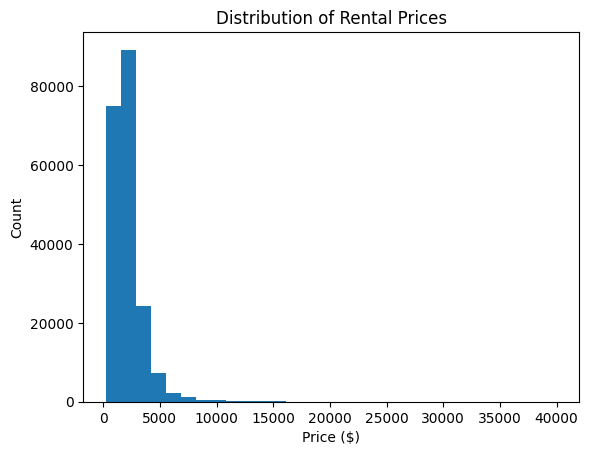

In [ ]:
# Histogram: Price
plt.hist(df['price'], bins=30)
plt.title("Distribution of Rental Prices")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

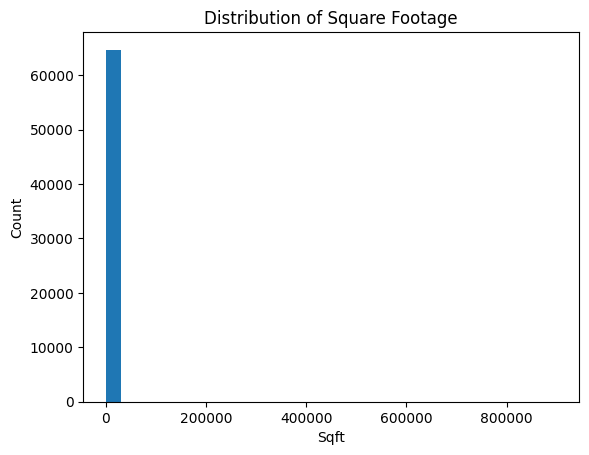

In [ ]:
# Histogram: Square Footage
plt.hist(df['sqft'].dropna(), bins=30)
plt.title("Distribution of Square Footage")
plt.xlabel("Sqft")
plt.ylabel("Count")
plt.show()


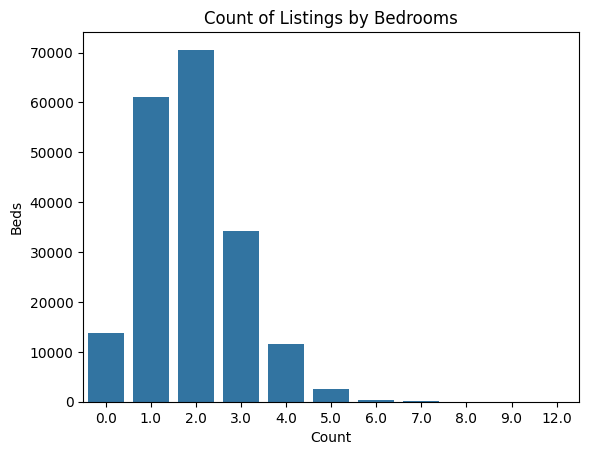

In [ ]:
# Countplot for beds
sns.countplot(data=df, x='beds')
plt.title("Count of Listings by Bedrooms")
plt.xlabel("Count")
plt.ylabel("Beds")
plt.show()

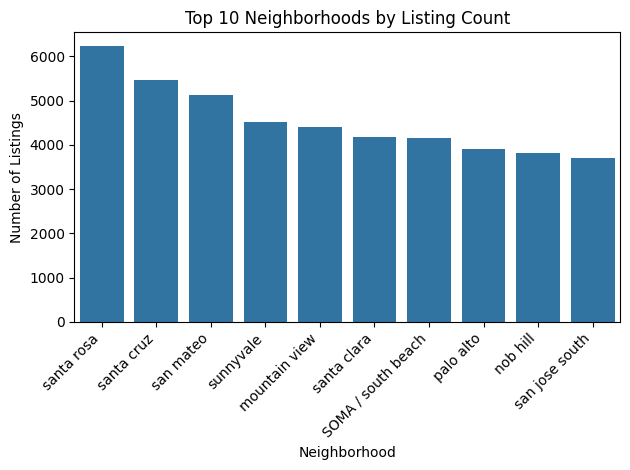

In [ ]:
# Bar plot of top 10 neighborhoods by number of listings
top_nhoods = df['nhood'].value_counts().head(10)

# we have 167 different neighborhoods stored as a categorical variable - lets remove the ones not in the top 10
top_nhoods.index = top_nhoods.index.remove_unused_categories()

# now plot a barplot
sns.barplot(x=top_nhoods.index, y=top_nhoods.values, order = top_nhoods.index)
plt.title("Top 10 Neighborhoods by Listing Count")
plt.xlabel("Neighborhood")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **🔧 Try It Yourself – Part 3**

3.1 -3.2 Create two new *visualizations* using different variables than the ones already shown above. Be sure to label your axes and include a title for each chart.

>Suggestions:
- A **histogram** of the `baths` variable
- A **bar chart** showing the *average square footage by number of bathrooms*

3.3 - 3.4. After creating the visuals, write 1–2 sentences explaining what you notice in each as a comment.

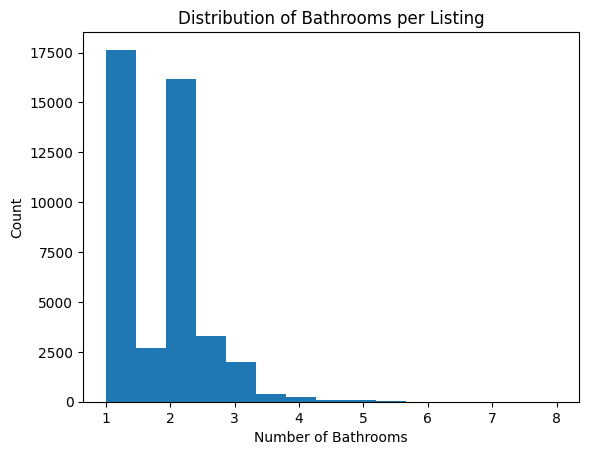

In [ ]:
# 🔧 3.1. Visual 1 # 🔧 3.1. Visual 1
plt.hist(df['baths'].dropna(), bins=15)
plt.title("Distribution of Bathrooms per Listing")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Count")
plt.show()



### ✍️ Visual 1 Response: 🔧

3.3.



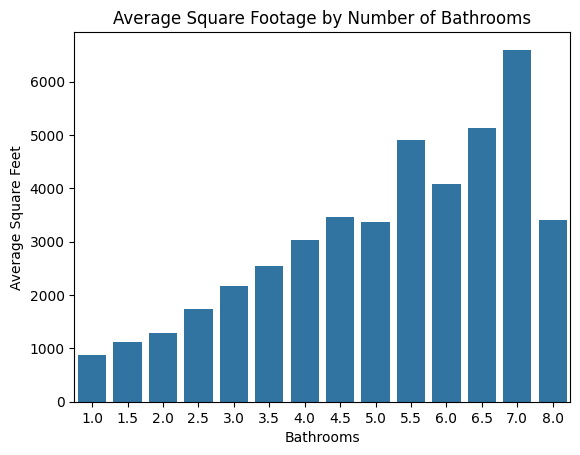

In [ ]:
# 🔧 3.2. Visual 2
# 🔧 3.2. Visual 2
avg_sqft_baths = df.groupby('baths')['sqft'].mean().dropna()
sns.barplot(x=avg_sqft_baths.index, y=avg_sqft_baths.values)
plt.title("Average Square Footage by Number of Bathrooms")
plt.xlabel("Bathrooms")
plt.ylabel("Average Square Feet")
plt.show()


### ✍️ Visual 2 Response: 🔧
3.4. Average square footage rises steadily with the number of bathrooms, from about 880 sqft for 1 bath to about 3,000 sqft for 4 baths. Above 5 baths the bars jump around because only a handful of listings are in those groups, so those averages aren't very reliable.

## **Part 4: Bivariate Analysis**

Explore *relationships* between two variables to understand how *features* like `sqft` or `beds` influence `price`.

In [ ]:
# Correlation matrix
corr_matrix = df[['price', 'beds', 'baths', 'sqft']].corr()
corr_matrix


,price,beds,baths,sqft
price,1.000000,0.450096,0.433553,0.074310
beds,0.450096,1.000000,0.651835,0.707235
baths,0.433553,0.651835,1.000000,0.645372
sqft,0.074310,0.707235,0.645372,1.000000


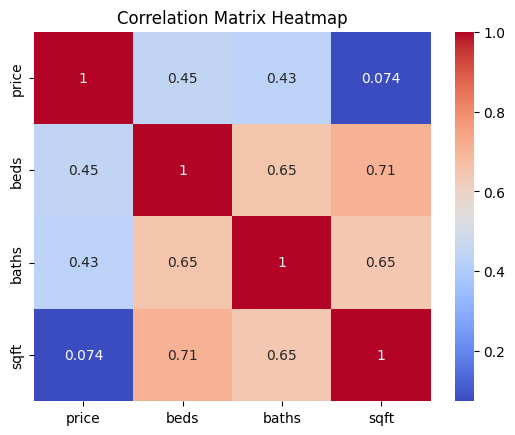

In [ ]:
# Heatmap of correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix Heatmap")
plt.show()

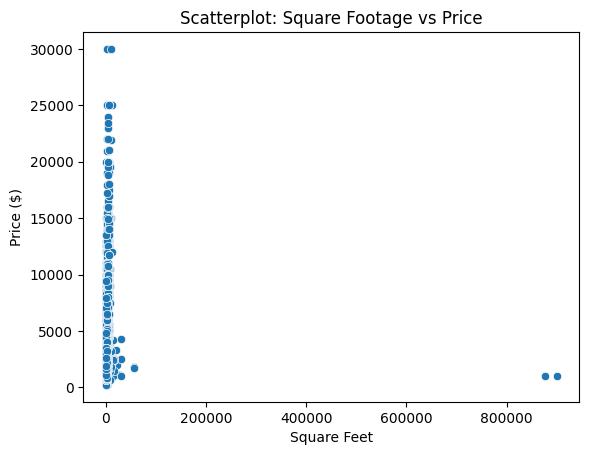

In [ ]:
# Scatterplot: Square Footage vs Price
sns.scatterplot(x='sqft', y='price', data=df)
plt.title("Scatterplot: Square Footage vs Price")
plt.xlabel("Square Feet")
plt.ylabel("Price ($)")
plt.show()

NOTE: The outlier(s) in `sqft` essentially dominate this plot. The EDA is useful in showing us outliers and how they might be affecting key *target* variables or outcomes.

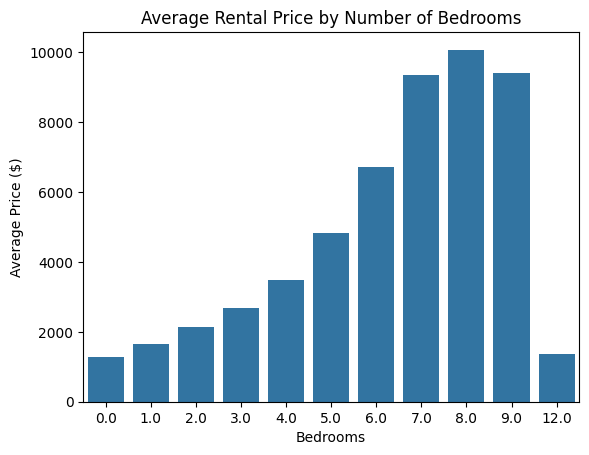

In [ ]:
# Average price by number of bedrooms
avg_price_beds = df.groupby('beds')['price'].mean().sort_index()
sns.barplot(x=avg_price_beds.index, y=avg_price_beds.values)
plt.title("Average Rental Price by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Price ($)")
plt.show()

### **🔧 Try It Yourself – Part 4**

4.1. Create a **scatterplot** of `baths` vs `price`.

4.2. Group by `year` and plot the average price over time.

4.3. What *trends* or *outliers* do you see?

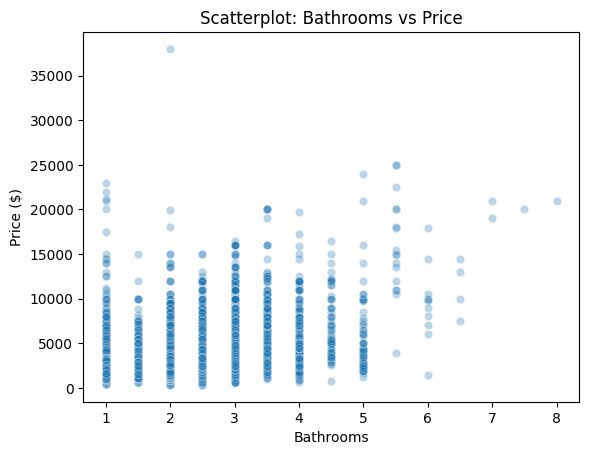

In [ ]:
#🔧5.1  Your code here # 🔧 4.1 Scatterplot: Bathrooms vs Price
sns.scatterplot(x='baths', y='price', data=df, alpha=0.3)
plt.title("Scatterplot: Bathrooms vs Price")
plt.xlabel("Bathrooms")
plt.ylabel("Price ($)")
plt.show()

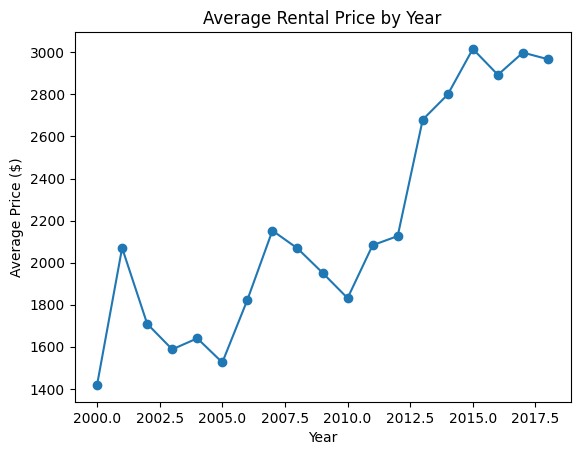

In [ ]:
# 🔧5.2  Your code here # 🔧 4.2 Average price by year
avg_price_year = df.groupby('year')['price'].mean()
plt.plot(avg_price_year.index, avg_price_year.values, marker='o')
plt.title("Average Rental Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Price ($)")
plt.show()

### ✍️ Your Response: 🔧

4.3 . Price generally increases with the number of bathrooms, from about $1,860 on average for 1 bath to about $3,750 for 3 baths, but there is a lot of spread within each group and a few extreme listings near $40,000 stand out as outliers. Over time, average rent stayed roughly between $1,500 and $2,150 from 2001 to 2012, then jumped sharply to about $2,700 in 2013 and around $3,000 by 2015, leveling off through 2018. Early years like 2000 have very few listings, so their averages are less reliable.

## **Part 5: Reflection 🔧**

Answer the following questions in the Markdown cell below (no more than a few sentences per question required)

5.1. Which variables are most strongly correlated with rental `price`?

5.2. Are there patterns in how `sqft` or number of bedrooms `beds` affects `price`?

5.3. Which `neighborhoods` or `year` show the highest `price`?

5.4. What other visualizations or groupings might improve this analysis?

Use this section to summarize insights from Lab 5 (and 4).

### ✍️ Your Response: 🔧


5.1.
Bedrooms (r = 0.45) and bathrooms (r = 0.43) have the strongest correlations with price, both moderate and positive. Square footage is surprisingly weak (r = 0.07), but that is likely distorted by extreme outliers such as a 900,000 sqft entry, since sqft is strongly correlated with beds (0.71) and baths (0.65).

5.2.
Average price rises consistently with bedrooms, from about 1,280 USD for studios to 1,650 for 1 bed, 2,150 for 2 beds, 2,680 for 3 beds, and 3,490 for 4 beds. The sqft vs price relationship is hard to see in the scatterplot because a few extreme sqft values compress everything else; removing outliers would likely reveal a clearer positive trend.

5.3.
Among neighborhoods with at least 100 listings, Atherton has the highest average price (about 4,540 USD), followed by Tiburon/Belvedere (about 4,270) and the Financial District (about 3,960). By year, 2015 had the highest average price at about 3,020 USD, with 2017 and 2018 close behind at around 3,000.

5.4.
Removing or capping outliers in price and sqft would make the scatterplots and correlations more meaningful. Other useful views would be boxplots of price by bedrooms or by county, price per square foot by neighborhood, comparing full apartments vs single rooms (room_in_apt), and a map using lat/lon to show geographic price differences.



## Export Your Notebook to Submit in Canvas
- Use the instructions from Lab 1

In [ ]:
!jupyter nbconvert --to html "lab_05_AbdullahLaith.ipynb"

[NbConvertApp] WARNING | pattern 'lab_05_AbdullahLaith.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--ex

## Submit your assignment

- Make sure that all of your output is shown.
When there are multiple subtasks, good ideas to write code for each in its own cell.
- If you use AI, it is your responsibility to clean up the AI code. Only keep the outputs relevant to each subtask or task question.
- Upload your HTML file to Canvas. make sure that your lastnamefirstname are part of the filename as requested above
- Optionally, save your file in your own GitHub account for future use